# **Reinforcement learning tutorial**
In today's tutorial, you will learn how apply Q-learning algorithm and deep Q-networks to simulated environments.

We will use the [**TensorFlow**](https://www.tensorflow.org/) framework and the [**Keras**](https://keras.io/) open-source library to rapidly prototype deep neural networks, and the [**Gymnasium**](https://gymnasium.farama.org/) open-source library to simulate reinforcement learning environments.

Gymnasium offers a standardized API for interacting with reinforcement learning environments and a diverse set of reference environments, enabling reproducible development and comparison of reinforcement learning algorithms.

# **Preliminary operations**
The following code downloads all the necessary material into the remote machine. At the end of the execution select the **File** tab to verify that everything has been correctly downloaded.

In [1]:
!wget https://biolab.csr.unibo.it/ferrara/Courses/DL/Tutorials/RL/BreakoutDeterministic-v4_DQN_Weights.zip

!unzip BreakoutDeterministic-v4_DQN_Weights.zip -d /content/breakout_weights/

!rm BreakoutDeterministic-v4_DQN_Weights.zip

--2026-05-04 07:20:48--  https://biolab.csr.unibo.it/ferrara/Courses/DL/Tutorials/RL/BreakoutDeterministic-v4_DQN_Weights.zip
Resolving biolab.csr.unibo.it (biolab.csr.unibo.it)... 137.204.72.188
Connecting to biolab.csr.unibo.it (biolab.csr.unibo.it)|137.204.72.188|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18846722 (18M) [application/x-zip-compressed]
Saving to: ‘BreakoutDeterministic-v4_DQN_Weights.zip’

BreakoutDeterminist 100%[===================>]  17.97M  1.35MB/s    in 33s     

2026-05-04 07:21:22 (563 KB/s) - ‘BreakoutDeterministic-v4_DQN_Weights.zip’ saved [18846722/18846722]

Archive:  BreakoutDeterministic-v4_DQN_Weights.zip
  inflating: /content/breakout_weights/BreakoutDeterministic-v4_DQN_Weights_15000ep.h5  
  inflating: /content/breakout_weights/BreakoutDeterministic-v4_DQN_Weights_22751ep.h5  
  inflating: /content/breakout_weights/BreakoutDeterministic-v4_DQN_Weights_5000ep.h5  


The following code installs [**PyVirtualDisplay**](https://github.com/ponty/pyvirtualdisplay), a utility for creating a virtual display used to render environments when no physical display is available.

In [2]:
!pip install pyvirtualdisplay

# **Useful modules import**
First of all, it is necessary to import useful modules used during the tutorial.

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import ale_py
import random
import time
import statistics
import cv2
import uuid
from IPython.display import HTML
from base64 import b64encode
from IPython.display import clear_output
from tensorflow import keras
from tensorflow.keras import layers
from skimage import transform
from skimage.color import rgb2gray
from collections import deque
from pyvirtualdisplay import Display

# **Utility functions**
Execute the following code to define some utility functions used in the tutorial:
- **print_taxi_step** draws a single frame of the taxi environment with the corresponding information;
- **print_taxi_single_episode** visualizes an entire episode of the taxi environment;
- **plot_training_rewards** draws in a graph the total reward trend and its moving average reached during the different episodes of the training process;
- **plot_stacked_frames** shows a stack of frames;
- **create_mp4_video_from_frames** creates an MP4 video file from a list of frames.

In [4]:
def print_taxi_step(frame,episode,step,state,action,reward,current_total_reward):
  print(frame)
  if episode!=None:
    print('Episode: ',episode)
  if step!=None:
    print('Step: ',step)
  print('State: ',state)
  print('Action: ',action)
  print('Reward: ',reward)
  print('Total reward: ',current_total_reward)

def print_taxi_single_episode(frames,max_steps=50,seconds_to_sleep=.1,episode=None):
  for i, frame in enumerate(frames):
    if i>=max_steps:
      break

    clear_output(wait=True)
    print_taxi_step(frame['frame'],episode,i,frame['state'],frame['action'],frame['reward'],frame['total_reward'])
    time.sleep(seconds_to_sleep)

def plot_training_rewards(rewards,moving_avg_window_size=None):
  if moving_avg_window_size is not None:
    moving_avg_total_reward=[]
    for i in range(len(rewards)):
      window=rewards[max(0,i-moving_avg_window_size+1):i+1]
      window_avg=statistics.mean(window)
      moving_avg_total_reward.append(window_avg)

  fig, ax = plt.subplots(figsize=(15, 5))

  ax.plot(range(len(rewards)),rewards,label='Total reward',color='orange')
  ax.set_xlabel('Episodes')
  if moving_avg_window_size is not None:
    ax.plot(range(len(moving_avg_total_reward)),moving_avg_total_reward,label='Total reward moving average')
    ax.legend(loc='upper left')

def plot_stacked_frames(stacked_frames):
  _,axs=plt.subplots(1,stacked_frames.shape[2],figsize=(15,5))
  for i in range(stacked_frames.shape[2]):
    axs[i].axis('off')
    axs[i].imshow(stacked_frames[:,:,i],cmap='gray')

def create_mp4_video_from_frames(frames,fps):
  temp_video_path='tempfile.mp4'
  compressed_path='{}.mp4'.format(str(uuid.uuid4()))

  size=(frames[0].shape[1],frames[0].shape[0])
  out = cv2.VideoWriter(temp_video_path,cv2.VideoWriter_fourcc(*'mp4v'), fps, size)

  for i in range(len(frames)):
      out.write(frames[i][...,::-1].copy())
  out.release()

  os.system(f"ffmpeg -i {temp_video_path} -vcodec libx264 {compressed_path}")

  os.remove(temp_video_path)

  return compressed_path

# **Q-learning with self-driving taxi**
In this section, the Q-Learning algorithm is applied to a self-driving taxi that will need to learn how to transport its passengers to the desired destination.

To this purpose, the [**Taxi**](https://www.gymlibrary.dev/environments/toy_text/taxi/) environment provided by Gymnasium will be used:

"*There are 4 locations (labeled by different letters), and our job is to pick up the passenger at one location and drop him off at another. We receive +20 points for a successful drop-off and lose 1 point for every time-step it takes. There is also a 10 point penalty for illegal pick-up and drop-off actions.*"

## **Taxi environment**
The environment is represented by a training area for the self-driving taxi where to learn transport people in four different locations (R, G, Y, B):

<img src=https://biolab.csr.unibo.it/ferrara/Courses/DL/Tutorials/RL/Reinforcement_Learning_Taxi_Env.png width="400">

### **Creation**
The following code initializes the Taxi environment using the [**make**](https://gymnasium.farama.org/api/registry/#gymnasium.make) method.

In [7]:
env = gym.make('Taxi-v4',render_mode='ansi')

### **Visualization**
To visualize the environment, the [**reset**](https://gymnasium.farama.org/api/env/#gymnasium.Env.reset) method is firstly called to start a new episode then the [**render**](https://gymnasium.farama.org/api/env/#gymnasium.Env.render) method can be used:
- the filled square represents the taxi, which is yellow without a passenger and green with a passenger;
- the pipe ("|") represents a wall which the taxi cannot cross;
- R, G, Y, B are the possible pickup and destination locations. The blue letter represents the current passenger pick-up location, and the purple letter is the current destination.

In [11]:
env.reset()
print(env.render())

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




### **State space**
Assuming self-driving taxi is the only vehicle in this parking lot, the parking lot can be divided into a $5\times 5$ grid, obtaining 25 possible taxi locations. Four of them are locations where the taxi can pick up and drop off a passenger: R, G, Y, B or $[(0,0), (0,4), (4,0), (4,3)]$ in $(row, col)$ coordinates.

Moreover, there are 4 possible destinations and 5 (R, G, Y, B or inside the taxi) passenger locations.

The taxi environment has $5\times 5\times 5\times 4=500$ total possible states.

Every Gymnasium environment comes with an [**observation_space**](https://gymnasium.farama.org/api/env/#gymnasium.Env.observation_space) attribute describing the format of valid observations (or states). If the space is composed by a fixed number of discrete values, an instance of the [**Discrete**](https://gymnasium.farama.org/api/spaces/fundamental/#gymnasium.spaces.Discrete) space class is returned and the **n** property can be used to get the cardinality of the space.

In [12]:
print('There are {} possible states'.format(env.observation_space.n))

There are 500 possible states


### **Action space**
The action space is composed by six possible actions:
- south;
- north;
- east;
- west;
- pickup;
- dropoff.

Every Gymnasium environment comes with an [**action_space**](https://gymnasium.farama.org/api/env/#gymnasium.Env.action_space) attribute describing the format of valid actions. As for the state space, the action space is discrete and the number of possible actions can be retrieved by the **n** property.

In [13]:
print('There are {} possible actions'.format(env.action_space.n))

There are 6 possible actions


### **Rewards**
The rewards are:
- -1 for each step;
- -1 for every wall hit (the taxi will not move anywhere);
- -10 for illegal actions (pick up or put down the passenger in the wrong location);
- +20 for successfully deliver the passenger.

## **Exercise 1: Q-learning algorithm**
Implement the **q_learning** function given:
- the environment (*env*);
- the number of episodes (*episode_count*);
- the maximum number of steps per episode (*episode_max_steps*);
- the maximum value of $\epsilon$ (*max_epsilon*);
- the minimum value of $\epsilon$ (*min_epsilon*);
- the $\epsilon$ decay value (*epsilon_decay*);
- the learning rate $\alpha$ (alpha);
- the discount factor $\gamma$ (gamma).

It returns the learned Q-table (*Q*) and a **List** (*learning_history*) containing useful information to visualize the agent progresses during the learning process.

The following image shows the pseudo-code of the *Q-learning* algorithm.

<img src=https://biolab.csr.unibo.it/ferrara/Courses/DL/Tutorials/RL/Q_learning_algorithm.png width="800">

The following parts need to be implemented:
1. initialize *Q* as a Numpy zero matrix with as many rows as the states and as many columns as the actions. The [**zeros**](https://numpy.org/doc/stable/reference/generated/numpy.zeros.html) function provided by the Numpy module can be used;
2. initialize $\epsilon$ equal to *max_epsilon*;
3. call the **reset** method provided by the Gymnasium environment interface to reset the environment and get the random initial state ($s_0$);
4. decide whether to pick a random action or to exploit the already computed Q-values. To this purpose, the **uniform** function provided by the [**random**](https://docs.python.org/3/library/random.html) module can be used to generate a random number in the range $[0;1]$ to be compared against $\epsilon$. If a random action needs to be selected from the set of all possible actions, the **action_space.sample** method provided by the Gymnasium environment can be exploited. Otherwise, use the [**argmax**](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) function provided by Numpy to select the optimal action for state $s_t$;
5. call the [**step**](https://gymnasium.farama.org/api/env/#gymnasium.Env.step) method provided by the Gymnasium environment interface to
execute the action $a_t$ selected at the previous point. It returns the new observation (or state) $s_{t+1}$, the reward $r_{t+1}$ achieved by action $a_t$, two boolean flags indicating if the episode has ended (*True*) or not (*False*) and other additional information;
6. update $Q(s_t,a_t)$ using the *Bellman* equation. The Numpy [**amax**](https://numpy.org/doc/stable/reference/generated/numpy.amax.html) function can be used to find the maximum value of $Q(s_{t+1},a)$;
7. reduce $\epsilon$. It is progressively reduced during the learning process because, while the agent learns more and more about the environment, less and less exploration will be needed;

In [14]:
def q_learning(env,episode_count,episode_max_steps,max_epsilon,min_epsilon,epsilon_decay,alpha,gamma):
  # 1. initialize Q as a zero matrix with as many rows as the states and as many columns as the actions
  Q = np.zeros(shape=(env.observation_space.n, env.action_space.n))

  learning_history = [] # for visualization purposes

  # 2. inizialize epsilon equal to max_epsilon
  epsilon = max_epsilon

  for episode in range(episode_count):
      # for visualization purposes
      episode_history = []
      episode_total_reward=0

      # 3. reset the environment (every time an episode finishes we have to reset the env clearly)
      state, _ = env.reset()

      step_count=0  #t
      done=False
      while (step_count<episode_max_steps) and (not done):
          # 4. decide whether to pick a random action or to exploit the already computed Q-values
          rand = random.uniform(0, 1)
          if rand <= epsilon:
             action = env.action_space.sample()
          else:
             action = np.argmax(Q[state])

          # 5. take the action and observe the outcome state and reward
          new_state, reward, terminated, truncated, _ = env.step(action)
          done = terminated or truncated

          # 6. update Q(s,a)
          Q[state][action] = (1-alpha) * Q[state][action] + alpha * (reward + gamma * np.amax(Q[new_state]))

          # put the current frame into a list for visualization purposes
          episode_total_reward += reward
          episode_history.append(
                                  {
                                  'frame': env.render(),
                                  'state': new_state,
                                  'action': action,
                                  'reward': reward,
                                  'total_reward' : episode_total_reward,
                                  }
                                )

          # update the current state
          state = new_state

          # increase the step count
          step_count+=1

      # 7. reduce epsilon
      if epsilon > min_epsilon:
        epsilon = max(min_epsilon, epsilon - epsilon_decay)

      # put all the episode frames into a list for visualization purposes
      learning_history.append(episode_history)

  # return Q-table and history
  return Q, learning_history

## **Learning**
Now we are ready to start the learning process by calling the **q_learning** function.

The following parameters must be set before being passed to the function:
- the number of episodes (*episode_count*);
- the maximum number of steps per episode (*episode_max_steps*);
- the maximum value of $\epsilon$ (*max_epsilon*);
- the minimum value of $\epsilon$ (*min_epsilon*);
- the $\epsilon$ decay value (*epsilon_decay*);
- the learning rate $\alpha$ (alpha);
- the discount factor $\gamma$ (gamma).

In [15]:
episode_count = 2000          # Total number of training episodes
episode_max_steps = 200       # Maximum number of steps per episode

max_epsilon = 1.0             # Exploration probability at start
min_epsilon = 0.001           # Minimum exploration probability
epsilon_decay = 0.01          # Decay for exploration probability

alpha = 0.5                   # Learning rate
gamma = 0.99                  # Discount factor

start_time = time.time()
Q,learning_history=q_learning(env,episode_count,episode_max_steps,max_epsilon,min_epsilon,epsilon_decay,alpha,gamma)
print('Learning time: {:.1f}s'.format(time.time() - start_time))

Learning time: 3.1s


### **Visualize the learning process**
It is important to observe how performance changes over time during the learning process.

The following code draws in a graph the number of steps and the total reward reached during the different episodes of the learning process.

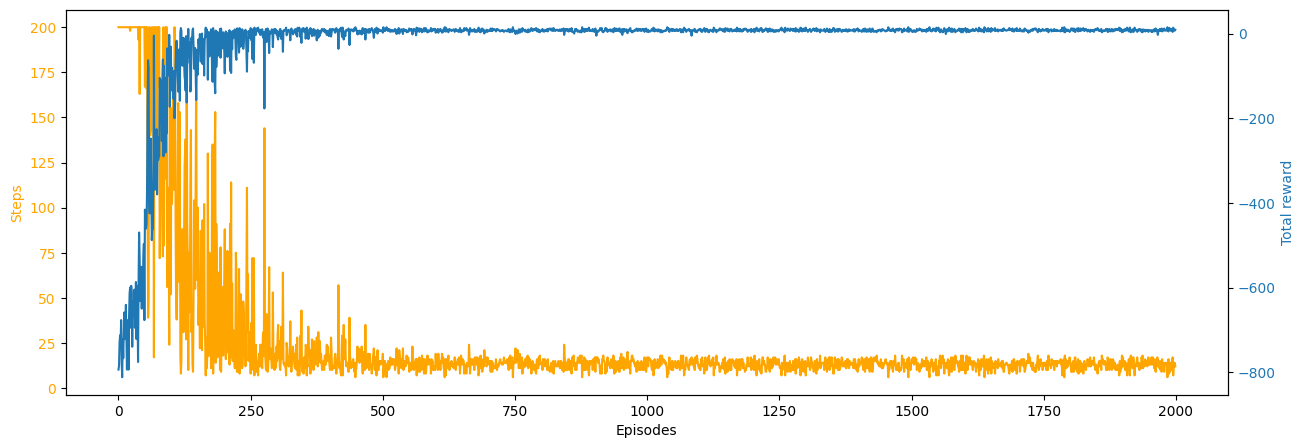

In [16]:
steps=[]
total_rewards=[]
for episode in learning_history:
  steps.append(len(episode))
  total_rewards.append(episode[-1]['total_reward'])

fig, ax1 = plt.subplots(figsize=(15, 5))

ax1.plot(range(len(steps)),steps,color='orange')
ax1.tick_params(axis='y', labelcolor='orange')
ax1.set_xlabel('Episodes')
ax1.set_ylabel('Steps',color = 'orange')

ax2 = ax1.twinx()
ax2.plot(range(len(total_rewards)),total_rewards,color='#1f77b4')
ax2.tick_params(axis='y', labelcolor='#1f77b4')
ax2.set_ylabel('Total reward',color='#1f77b4')

plt.show()

To better highlight how the self-driving taxi improves during the learning process, it is useful to visualize single episodes using the **print_taxi_single_episode** function defined above. The following code shows the first episode of the learning process (only the first 25 steps per episode are displayed).

In [19]:
print_taxi_single_episode(learning_history[2],25,0.5,0)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

Episode:  0
Step:  24
State:  233
Action:  0
Reward:  -1
Total reward:  -70


While initially the taxi randomly moves exploring the environment, at the end of the learning process the agent is perfectly capable to pickup a passenger and to transport him to the desired destination. The following code shows the last episode of the learning process.

In [23]:
print_taxi_single_episode(learning_history[-1],25,0.5,len(learning_history)-1)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Episode:  1999
Step:  11
State:  475
Action:  5
Reward:  20
Total reward:  9


## **Performance evaluation**
Now it is time to evaluate the performance of the self-driving taxi agent. It can be evaluated according to the following metrics:
- **average number of steps per episode**: the smaller the number, the shorter the path taken by the agent to reach the destination;
- **average total reward per episode**: a higher average reward means that the agent reaches the destination as fast as possible with the least penalties;
- **average number of penalties per episode**: it is computed as the average number of time per episode the agent executes an illegal action (pick up or put down the passenger in the wrong location). The smaller the number, the better the performance of our agent.

By running the following code the evaluation metrics will be computed as the average of the results on several (*test_episode_count*) episodes.

In [24]:
test_episode_count = 1000     # Total number of test episodes

sum_steps=0
sum_total_reward=0
sum_penalties=0

for episode in range(test_episode_count):
    state, _ = env.reset()
    for step in range(episode_max_steps):
        # Take the action (index) that have the maximum expected future reward given that state
        action = np.argmax(Q[state])
        new_state, reward, terminated, truncated, _ = env.step(action)

        sum_steps+=1
        sum_total_reward+=reward
        if reward == -10:
          sum_penalties += 1

        if terminated or truncated:
          break
        state = new_state

print ('Average number of steps per episode: {:.1f}'.format(sum_steps/test_episode_count))
print ('Average total reward per episode: {:.1f}'.format(sum_total_reward/test_episode_count))
print ('Average number of penalties per episode: {:.1f}'.format(sum_penalties/test_episode_count))

Average number of steps per episode: 13.0
Average total reward per episode: 8.0
Average number of penalties per episode: 0.0


## **Single episode visualization**
The following code shows the self-driving in action on a single episode using the **print_taxi_step** function.

In [27]:
episode_total_reward = 0

state, _ = env.reset()
done=False
step=0
while not done:
    action = np.argmax(Q[state])
    new_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    episode_total_reward+=reward
    clear_output(wait=True)
    print_taxi_step(env.render(),None,step,new_state,action,reward,episode_total_reward)
    time.sleep(0.5)

    state = new_state
    step+=1

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Step:  13
State:  0
Action:  5
Reward:  20
Total reward:  7


# **Deep Q-network to solve the CartPole environment**
In this section, a Deep Q-Network (DQN) model is trained to solve the [**CartPole**](https://gymnasium.farama.org/environments/classic_control/cart_pole/) environment provided by Gymnasium.

## **CartPole environment**
The environment is represented by a pole attached to a cart which moves along a frictionless track. The objective is to prevent pole from falling over. The episode ends when the pole is more than 15 degrees from vertical, or the cart moves far from the center.

### **Creation**
The following code creates the CartPole environment.

In [28]:
env = gym.make('CartPole-v1',render_mode='rgb_array')

### **Visualization**
To visualize the environment on *Colab*, PyVirtualDisplay is used to create a virtual display.

The following code creates a virtual display where the environment can be rendered.

In [29]:
display = Display()
display.start()

To visualize the current state of the environment, the **render** method can be used.

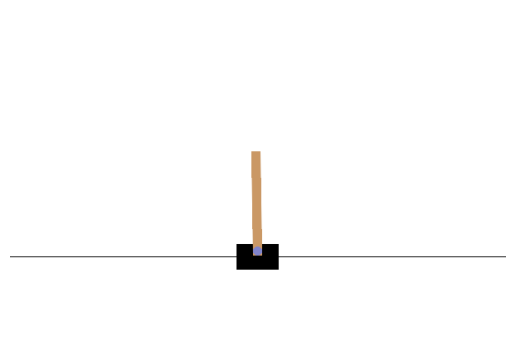

In [31]:
env.reset()
prev_screen = env.render()
plt.axis('off')
plt.imshow(prev_screen)
plt.show()

### **State space**
Differently from Taxi environment, the CartPole state space is represented by 4 continuous real values (not anymore discrete actions):
- cart Position;
- cart Velocity;
- pole angle;
- pole angular velocity.

In this case, the **observation_space** attribute returns a [**Box**](https://gymnasium.farama.org/api/spaces/fundamental/#gymnasium.spaces.Box) space class instance where valid states are in the form of *n*-dimensional arrays. The *shape* of the space can be obtained by the **shape** property.

In [32]:
print('State space shape: ',env.observation_space.shape)

State space shape:  (4,)


### **Action space**
The action space is composed by two possible actions:
- push cart to the left;
- push cart to the right.

The following code uses the **n** property of the action space to print the number of valid actions.

In [33]:
print('There are {} possible actions'.format(env.action_space.n))

There are 2 possible actions


### **Rewards**
Reward is 1 for every step taken, including the termination step.

## **Model definition**
The following function creates a simple neural network to be used as DQN given:
- the number of input features (*input_count*);
- the number of neurons for each hidden layer (*neuron_count_per_hidden_layer*);
- the number of valid actions (*action_count*).

In Keras, a sequential is a stack of layers where each layer has exactly one input and one output. It can be created by passing a list of layers to the  constructor [**keras.Sequential**](https://keras.io/guides/sequential_model/).

[**Keras layers API**](https://keras.io/api/layers/) offers a wide range of built-in layers ready for use, including:
- [**Input**](https://keras.io/api/layers/core_layers/input/) - the input of the model. Note that, the **Input** is optional: in that case the model does not have any weights until the first call to a training/evaluation method (since it is not yet built);
- [**Dense**](https://keras.io/api/layers/core_layers/dense/) - a fully-connected layer.

In [34]:
def build_simple_dqn(input_count,neuron_count_per_hidden_layer,action_count):
    model = keras.Sequential()
    model.add(layers.Input(shape=input_count,name='Input'))

    for n in neuron_count_per_hidden_layer:
        model.add(layers.Dense(n,activation='relu'))

    model.add(layers.Dense(action_count,name='Output'))

    return model

## **Action and target models creation**
To solve the *moving target problem*, two models (*action* and *target*) are used during the DQN training process.

The following code creates two identical models by calling the **build_simple_dqn** function defined above. To be identical, the two models need to share initial random weights: [**get_weights**](https://keras.io/api/layers/base_layer/#getweights-method) and [**set_weights**](https://keras.io/api/layers/base_layer/#setweights-method) methods are used to replace target weights to those of the action model.

In [35]:
neuron_count_per_hidden_layer=[64,32]

simple_dqn_action_model=build_simple_dqn(env.observation_space.shape,neuron_count_per_hidden_layer,int(env.action_space.n))
simple_dqn_target_model=build_simple_dqn(env.observation_space.shape,neuron_count_per_hidden_layer,int(env.action_space.n))
simple_dqn_target_model.set_weights(simple_dqn_action_model.get_weights())

## **Model visualization**
A string summary of the network can be printed using the [**summary**](https://keras.io/api/models/model/#summary-method) method.

In [36]:
simple_dqn_action_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,466 (9.63 KB)

 Trainable params: 2,466 (9.63 KB)

 Non-trainable params: 0 (0.00 B)

The summary is useful for simple models, but can be confusing for complex models.

Function [**keras.utils.plot_model**](https://keras.io/api/utils/model_plotting_utils/) creates a plot of the neural network graph that can make more complex models easier to understand.

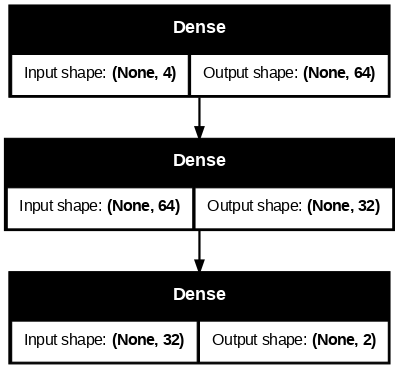

In [37]:
keras.utils.plot_model(simple_dqn_action_model,show_shapes=True, show_layer_names=False,dpi=80)

## **Action model compilation**
The compilation is the final step in configuring the model for training.

The following code uses the [**compile**](https://keras.io/api/models/model_training_apis/#compile-method) method to compile the model.
The important arguments are:
- the optimization algorithm (*optimizer*);
- the loss function (*loss*).

The most common [optimization algorithms](https://keras.io/api/optimizers/#available-optimizers) and [loss functions](https://keras.io/api/losses/#available-losses) are already available in Keras. You can either pass them to **compile** as an instance or by the corresponding string identifier. In the latter case, the default parameters will be used.

<u>Note that, only the action model is compiled because, during the training process, only its weights are updated using *gradient descent* algorithm. Target model weights are periodically replaced by those of the action model.</u>

In [38]:
simple_dqn_action_model.compile(optimizer='adam', loss = 'mse')

## **Experience replay**
To remove correlations between consecutive transitions and make the DQN training more stable, the *experience replay* technique is used.

The replay memory is implemented as a [**deque**](https://docs.python.org/3/library/collections.html#collections.deque) (Doubly Ended Queue) object providing an O(1) time complexity for append and pop operations from both the ends of the queue. Moreover, if the *maxlen* parameter is specified, the **deque** is bounded to the specified maximum length. Once a bounded length deque is full, when new items are added, a corresponding number of items are discarded from the opposite end.

The DQN authors suggest to populate the replay memory before starting the learning process. For each step $t$, a random action is chosen and executed then the transition $<s_t,a_t,r_{t+1},s_{t+1}>$ is stored in the replay memory. The following function initializes the replay memory given:
- the environment (*env*);
- the replay memory (*replay_memory*);
- the number of transitions to be stored in the replay memory (*replay_memory_init_size*);
- the maximum number of steps per episode (*episode_max_steps*).


In [39]:
def simple_dqn_replay_memory_init(env,replay_memory,replay_memory_init_size,episode_max_steps):
    while True:
        state, _ = env.reset()
        done=False
        step_count=0
        while (step_count<episode_max_steps) and (not done):
            action = env.action_space.sample()
            new_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            replay_memory.append([state,action,reward,new_state,done])
            state=new_state
            step_count+=1
            if len(replay_memory)>=replay_memory_init_size:
                return

During training, when the action model needs to be updated, a mini-batch is randomly sampled from the replay memory and used instead of the most recent transition. The following function returns a mini-batch containing transitions randomly chosen from the replay memory given:
- the replay memory (*replay_memory*);
- the mini-batch size (*batch_size*).

In [40]:
def get_random_batch_from_replay_memory(replay_memory,batch_size):
    minibatch_indices = np.random.choice(range(len(replay_memory)), size=batch_size)
    minibatch = [replay_memory[i] for i in minibatch_indices]

    state_batch = np.array([sample[0] for sample in minibatch])
    action_batch = np.array([sample[1] for sample in minibatch])
    reward_batch = np.array([sample[2] for sample in minibatch])
    new_state_batch = np.array([sample[3] for sample in minibatch])
    done_batch = np.array([sample[4] for sample in minibatch])

    return [state_batch,action_batch,reward_batch,new_state_batch,done_batch]

## **Exercise 2: DQN training algorithm**
Implement the following function to train a DQN model given:
- the environment (*env*);
- the action model (*dqn_action_model*);
- the target model (*dqn_target_model*);
- the number of episodes (*episode_count*);
- the maximum number of steps per episode (*episode_max_steps*);
- the maximum number of transitions stored into the replay memory (*replay_memory_max_size*);
- the number of transitions stored into the replay memory before starting the training process (*replay_memory_init_size*);
- the mini-batch size (*batch_size*);
- the number ($u$) of total steps executed ($T$) between successive updates of the action model weights (*step_per_update*);
- the number ($c$) of total steps executed ($T$) between successive replaces of the target model weights with the weights of the action model (*step_per_update_target_model*);
- the maximum value of $\epsilon$ (*max_epsilon*);
- the minimum value of $\epsilon$ (*min_epsilon*);
- the $\epsilon$ decay value (*epsilon_decay*);
- the discount factor $\gamma$ (gamma);
- the number of consecutive episodes to be considered in the calculation of the total reward moving average (*moving_avg_window_size*);
- the minimum value of the total reward moving average to consider the task solved (*moving_avg_stop_thr*). A value of *None* force to execute all *episode_count* episodes.

It returns a **List** (*train_rewards*) containing the total rewards of all training episodes.

The following image shows the pseudo-code of the DQN training algorithm.

<img src=https://biolab.csr.unibo.it/ferrara/Courses/DL/Tutorials/RL/DQN_training_algorithm.png width="800">

The following parts need to be implemented:
1. call the **simple_dqn_replay_memory_init** function to populate the replay memory before starting the training process;
2. initialize $\epsilon$ equal to *max_epsilon*;
3. call the **reset** method provided by the Gymnasium environment interface to reset the environment and get the random initial state ($s_0$);
4. decide whether to pick a random action or to exploit the already computed Q-values. To this purpose, the **uniform** function provided by the random module can be used to generate a random number in the range $[0;1]$ to be compared against $\epsilon$. If a random action needs to be selected from the set of all possible actions, the **action_space.sample** method provided by the Gymnasium environment can be exploited. Otherwise, use the [**predict**](https://keras.io/api/models/model_training_apis/#predict-method) method of the action model to obtain the Q-values of each available actions given the current state ($s_t$) and the  [**argmax**](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) function provided by Numpy to select the optimal one;
5. call the **step** method provided by the Gymnasium environment interface to
execute the action $a_t$ selected at the previous point. It returns the new observation (or state) $s_{t+1}$, the reward $r_{t+1}$ achieved by action $a_t$, two boolean flags indicating if the episode has ended (*True*) or not (*False*) and other additional information;
6. call the **get_random_batch_from_replay_memory** function to get a mini-batch of randomly selected transitions from the replay memory;
7. copy weights from action to target model using the **get_weights** and **set_weights** methods;
8. reduce $\epsilon$ at each step.

In [45]:
def simple_dqn_training(env,dqn_action_model,dqn_target_model,episode_count,episode_max_steps,
                        replay_memory_max_size,replay_memory_init_size,batch_size,
                        step_per_update,step_per_update_target_model,
                        max_epsilon,min_epsilon,epsilon_decay,gamma,
                        moving_avg_window_size=20,moving_avg_stop_thr=None):
    # experience replay memory declaration
    replay_memory= deque(maxlen=replay_memory_max_size)

    # 1. replay memory initial population
    if replay_memory_init_size>0:
        print('Replay memory initial population')
        simple_dqn_replay_memory_init(env, replay_memory, replay_memory_init_size, episode_max_steps)

    # 2. inizialize epsilon equal to max_epsilon
    epsilon = max_epsilon

    train_rewards=[]  # for visualization purposes

    train_step_count=0  #T
    for n in range(episode_count):
        # for visualization purposes
        episode_start_time = time.time()
        episode_reward = 0
        episode_epsilon=epsilon

        # 3. reset the environment
        state, _ = env.reset()

        step_count=0  #t
        done=False
        while step_count<episode_max_steps and not done:
            # 4. decide whether to pick a random action or to exploit the already computed Q-values
            if random.uniform(0,1) >= epsilon:
                action = env.action_space.sample()
            else:
                # nota: prediction prendono robe in pacchetti, quindi dobbiamo andare a specificarlo
                q_values = dqn_action_model.predict(state[np.newaxis], verbose = 0) # sta roba mi ha fregato
                action = np.argmax(q_values)

            # 5. take the action and observe the outcome state and reward
            new_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # store transition in the replay memory
            replay_memory.append([state,action,reward,new_state,done])

            # update the current state
            state=new_state

            if train_step_count % step_per_update == 0 and len(replay_memory)>=batch_size:
                # 6. get a random mini-batch from the replay memory
                mini_batch = get_random_batch_from_replay_memory(replay_memory, batch_size)

                # update the action model weights calling the simple_dqn_update function (see below)
                dqn_action_model=simple_dqn_update(dqn_action_model,dqn_target_model,mini_batch,gamma)

            if train_step_count % step_per_update_target_model ==0:
                # 7. copy weights from action to target model
                dqn_target_model.set_weights(dqn_action_model.get_weights())

            # 8. reduce epsilon
            if epsilon > min_epsilon:
                epsilon = max(min_epsilon, epsilon - epsilon_decay)

            # increase episode step count and total step count
            step_count+=1
            train_step_count+=1

            # add the current reward to the episode total reward
            episode_reward += reward

        # put the episode total reward into a list for visualization purposes
        train_rewards.append(episode_reward)

        # for visualization purposes
        episode_finish_time=time.time()
        episode_elapsed_time=episode_finish_time-episode_start_time
        episode_avg_step_time=episode_elapsed_time/step_count
        moving_avg_reward=statistics.mean(train_rewards[-moving_avg_window_size:])
        print("Episode: {} Steps: {}[{}] Epsilon: {:.3f} Time: {:.1f}s[{:.2f}s]  Total reward: {}[{:.1f}]".format(n,
                                                                                                                  step_count,
                                                                                                                  train_step_count,
                                                                                                                  episode_epsilon,
                                                                                                                  episode_elapsed_time,
                                                                                                                  episode_avg_step_time,
                                                                                                                  episode_reward,
                                                                                                                  moving_avg_reward))

        # condition to consider the task solved
        if (moving_avg_stop_thr is not None) and moving_avg_reward>moving_avg_stop_thr:
            break

    # return a list containing the total rewards of all training episodes
    return train_rewards

### **Action model update**
Implement the **simple_dqn_update** function to update action model weights using *gradient descent* algorithm given:
- the action model (*dqn_action_model*);
- the target model (*dqn_target_model*);
- a mini-batch containing transitions $<s_i,a_i,r_{i+1},s_{i+1}>$ randomly selected from the replay memory (*mini_batch*);
- the discount factor $\gamma$ (gamma).

The following parts need to be implemented:
1. estimate $\hat{Q}(s_{i+1},a)$ for all possible actions using the **predict** method of the target model with *new_state_batch* ($s_{i+1}$) as input parameter;
2. estimate $Q(s_i,a)$ for all possible actions using the **predict** method of the action model with *state_batch* ($s_i$) as input parameter;
3. update weights of the action model using the [**train_on_batch**](https://keras.io/api/models/model_training_apis/#trainonbatch-method) method with *state_batch* ($s_i$) and *predicted_state_q_values* ($y_i$) as *x* and *y* input parameters, respectively.

In [44]:
def simple_dqn_update(dqn_action_model,dqn_target_model,mini_batch,gamma):
    # the transition mini-batch is divided into a mini-batch for each element of a transition
    state_batch,action_batch,reward_batch,new_state_batch,done_batch=mini_batch

    # 1. find the target model Q values for all possible actions given the new state batch
    target_new_state_q_values = dqn_target_model.predict(new_state_batch, verbose = 0)

    # 2. find the action model Q values for all possible actions given the current state batch
    predicted_state_q_values = dqn_action_model.predict(state_batch, verbose = 0)

    # estimate the target values y_i
    # for the action we took, use the target model Q values
    # for other actions, use the action model Q values
    # in this way, loss function will be 0 for other actions
    for i,(a,r,new_state_q_values, done) in enumerate(zip(action_batch,reward_batch,target_new_state_q_values, done_batch)):
        if not done:
          target_value = r + gamma * np.amax(new_state_q_values)
        else:
          target_value = r
        predicted_state_q_values[i][a] = target_value #y_i

    # 3. update weights of action model using the train_on_batch method
    dqn_action_model.train_on_batch(state_batch, predicted_state_q_values)

    # return the updated action model
    return dqn_action_model

## **Training**
Now we are ready to start the training process by calling the **simple dqn_learning** function.

The following parameters must be set before being passed to the function:
- the number of episodes (*episode_count*);
- the maximum number of steps per episode (*episode_max_steps*);
- the maximum number of transitions stored into the replay memory (*replay_memory_max_size*);
- the number of transitions stored into the replay memory before starting the training process (*replay_memory_init_size*);
- the mini-batch size (*batch_size*);
- the number of total steps executed between successive updates of the action model weights (*step_per_update*);
- the number of total steps executed between successive replaces of the target model weights with the weights of the action model (*step_per_update_target_model*);
- the maximum value of $\epsilon$ (*max_epsilon*);
- the minimum value of $\epsilon$ (*min_epsilon*);
- the $\epsilon$ decay value (*epsilon_decay*);
- the discount factor $\gamma$ (gamma);
- the number of consecutive episodes to be considered in the calculation of the total reward moving average (*moving_avg_window_size*);
- the minimum value of the total reward moving average to consider the task solved (*moving_avg_stop_thr*).

In [ ]:
episode_count = 500               # Total number of training episodes
episode_max_steps=400             # Maximum number of steps per episode

replay_memory_max_size = 100000   # Maximum number of transitions stored into the replay memory
replay_memory_init_size=1000      # Maximum number of transitions stored into the replay memory
batch_size = 64                   # Mini-batch size

step_per_update = 4               # Number of total steps executed between successive updates of the action model weights
step_per_update_target_model=8    # Number of total steps executed between successive replaces of the target model weights

max_epsilon=1.0                   # Exploration probability at start
min_epsilon=0.01                  # Minimum exploration probability
epsilon_decay=0.0002              # Decay for exploration probability

gamma = 0.99                      # Discount factor

moving_avg_window_size=20         # Number of consecutive episodes to be considered in the calculation of the total reward moving average

# aumenting this would make better performance
moving_avg_stop_thr=100           # Minimum value of the total reward moving average to consider the task solved

train_start_time=time.time()
train_rewards=simple_dqn_training(env,
                                  simple_dqn_action_model,
                                  simple_dqn_target_model,
                                  episode_count,
                                  episode_max_steps,
                                  replay_memory_max_size,
                                  replay_memory_init_size,
                                  batch_size,
                                  step_per_update,
                                  step_per_update_target_model,
                                  max_epsilon,
                                  min_epsilon,
                                  epsilon_decay,
                                  gamma,
                                  moving_avg_window_size,
                                  moving_avg_stop_thr)

train_finish_time=time.time()
train_elapsed_time=train_finish_time-train_start_time
train_avg_episode_time=train_elapsed_time/episode_count
print("Train time: {:.1f}m [{:.1f}s]".format(train_elapsed_time/60.0,train_avg_episode_time))

Replay memory initial population
Episode: 0 Steps: 10[10] Epsilon: 1.000 Time: 2.3s[0.23s]  Total reward: 10.0[10.0]
Episode: 1 Steps: 34[44] Epsilon: 0.998 Time: 3.7s[0.11s]  Total reward: 34.0[22.0]
Episode: 2 Steps: 43[87] Epsilon: 0.991 Time: 5.1s[0.12s]  Total reward: 43.0[29.0]
Episode: 3 Steps: 30[117] Epsilon: 0.983 Time: 4.2s[0.14s]  Total reward: 30.0[29.2]
Episode: 4 Steps: 20[137] Epsilon: 0.977 Time: 2.2s[0.11s]  Total reward: 20.0[27.4]
Episode: 5 Steps: 13[150] Epsilon: 0.973 Time: 1.4s[0.11s]  Total reward: 13.0[25.0]
Episode: 6 Steps: 9[159] Epsilon: 0.970 Time: 1.3s[0.14s]  Total reward: 9.0[22.7]
Episode: 7 Steps: 10[169] Epsilon: 0.968 Time: 1.2s[0.12s]  Total reward: 10.0[21.1]
Episode: 8 Steps: 10[179] Epsilon: 0.966 Time: 1.1s[0.11s]  Total reward: 10.0[19.9]
Episode: 9 Steps: 9[188] Epsilon: 0.964 Time: 1.2s[0.14s]  Total reward: 9.0[18.8]
Episode: 10 Steps: 8[196] Epsilon: 0.962 Time: 1.4s[0.18s]  Total reward: 8.0[17.8]
Episode: 11 Steps: 9[205] Epsilon: 0.961

### **Visualize the training process**
It is important to observe how performance changes over time during the training process.

The **plot_training_rewards** function defined above is used to draw in a graph the total reward and its moving average reached during the different episodes of the training process.

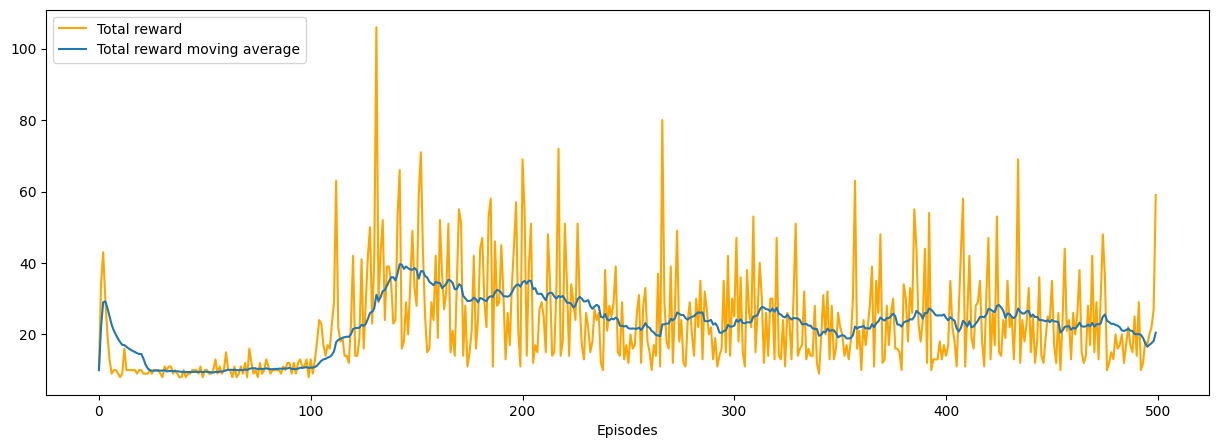

In [47]:
plot_training_rewards(train_rewards,moving_avg_window_size)

## **Performance evaluation**
The CartPole environment can be considered solved when the average total reward over 100 consecutive trials is greater than or equal to 195.

In [48]:
episode_count=5

sum_episode_rewards=0
for episode in range(episode_count):
  state, _ = env.reset()

  episode_reward = 0
  done=False
  step_count=0
  while not done:
      q_values = simple_dqn_action_model.predict(state[np.newaxis],verbose=0)
      action = np.argmax(q_values)

      new_state, reward, terminated, truncated, _ = env.step(action)
      done = terminated or truncated

      state = new_state
      episode_reward+=reward

  sum_episode_rewards+=episode_reward

  print('Episode: {} Total reward: {}'.format(episode,episode_reward))

print('Average total reward: {:.1f}'.format(sum_episode_rewards/episode_count))

Episode: 0 Total reward: 253.0
Episode: 1 Total reward: 145.0
Episode: 2 Total reward: 113.0
Episode: 3 Total reward: 113.0
Episode: 4 Total reward: 112.0
Average total reward: 147.2


## **Single episode visualization**
To show the CartPole agent in action on *Colab*, it is not possible to render each frame at real time.

It is necessary to:
1. execute an entire episode storing all episode frames;
2. create an MP4 video with all frames;
3. visualize the video.

The following code executes an episode using the trained DQN network and store all frames into a list (*frames*).

In [51]:
state, _ = env.reset()

frames=[]
done=False
episode_reward=0
while not done:
    frame = env.render()
    frames.append(frame)

    q_values = simple_dqn_action_model.predict(state[np.newaxis],verbose=0)
    action = np.argmax(q_values)

    new_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    state = new_state

    episode_reward+=reward

print('Total reward: ',episode_reward)

Total reward:  192.0


Then the MP4 video file, created using the **create_mp4_video_from_frames** function, is included into an HTML video tag.

In [52]:
vide_file_name=create_mp4_video_from_frames(frames,30)

mp4 = open(vide_file_name,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(""" <video controls><source src="%s" type="video/mp4"></video>""" % data_url)

# **Deep Q-network to solve the Atari Breakout environment**
In this section, a DQN model is trained to solve the [**Atari Breakout**](https://ale.farama.org/environments/breakout/) environment provided by the [**Arcade Learning Environment**](https://github.com/farama-foundation/arcade-learning-environment) framework.

## **Atari Breakout environment**
Breakout is an arcade game developed and published by Atari. In Breakout there are eight rows of bricks on the top of the screen and the player must knock down as many bricks as possible using a paddle, located at the bottom of the screen, to bounce a ball against them.

In this environment, the observation is an RGB image of the screen with a shape of (210, 160, 3).

### **Creation**
The following code creates the Atari Breakout environment.

In [53]:
env = gym.make('ALE/Breakout-v5',repeat_action_probability=0.0,render_mode='rgb_array')

### **Visualization**
To visualize the current state of the environment, the **render** method can be used.

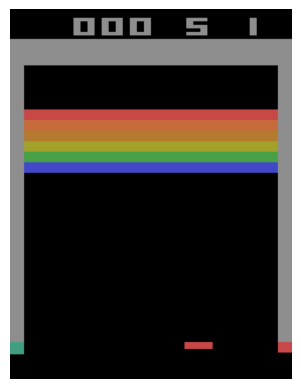

In [57]:
env.reset()
prev_screen = env.render()
plt.axis('off')
plt.imshow(prev_screen)
plt.show()

### **State space**
The state returned by the environment is an RGB image of $210\times 160$ pixels as reported by the **shape** property of the corresponding **observation_space** attribute.

In [58]:
print("The shape of the state space is: ", env.observation_space.shape)

The shape of the state space is:  (210, 160, 3)


### **Action space**
The action space is composed by four possible actions:
- noop;
- fire;
- right;
- left.

The following code uses the **n** property of the action space to print the number of valid actions.

In [59]:
print('There are {} possible actions'.format(env.action_space.n))

There are 4 possible actions


## **Exercise 3: model definition**
Implement the following function to create a DQN model given:
- the shape of the input images (*input_shape*);
- the number of valid actions (*action_count*).

The following image shows the architecture of DQN.

<img src=https://biolab.csr.unibo.it/ferrara/Courses/DL/Tutorials/RL/DQN_architecture.png width="1200">

Keras offers a wide range of built-in layers ready for use, including:
- [**Conv2D**](https://keras.io/api/layers/convolution_layers/convolution2d/) - a 2D convolution layer;
- [**Flatten**](https://keras.io/api/layers/reshaping_layers/flatten/) - a simple layer used to flatten the input.

In [60]:
def build_dqn(input_shape=(84, 84, 4),action_count=9):
    model = keras.Sequential(
        [
            layers.Input(shape=input_shape,name='Input'),
            layers.Conv2D(filters=32, kernel_size=8, strides=4,activation='relu',padding='valid',name='C1'),
            layers.Conv2D(filters=64, kernel_size=4, strides=2,activation='relu',padding='valid',name='C2'),
            layers.Conv2D(filters=64, kernel_size=3, strides=1,activation='relu',padding='valid',name='C3'),
            layers.Flatten(), # linearizziamo
            layers.Dense(units=action_count, activation='relu', name = 'Output')
        ]
    )
    return model

## **Action and target models creation**
The following code creates the action and target models by calling the **build_dqn** function defined above. To be identical, the two models need to share initial random weights: **get_weights** and **set_weights** methods are used to replace target weights to those of the action model.

In [61]:
dqn_action_model=build_dqn(action_count=int(env.action_space.n))
dqn_target_model=build_dqn(action_count=int(env.action_space.n))
dqn_target_model.set_weights(dqn_action_model.get_weights())

## **Model visualization**
A string summary of the network can be printed by executing the following code.

In [62]:
dqn_action_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ C1 (Conv2D)                     │ (None, 20, 20, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C2 (Conv2D)                     │ (None, 9, 9, 64)       │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ C3 (Conv2D)                     │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 4)              │        12,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,532 (353.64 KB)

 Trainable params: 90,532 (353.64 KB)

 Non-trainable params: 0 (0.00 B)

Alternatively, a plot of the neural network graph can be visualized.

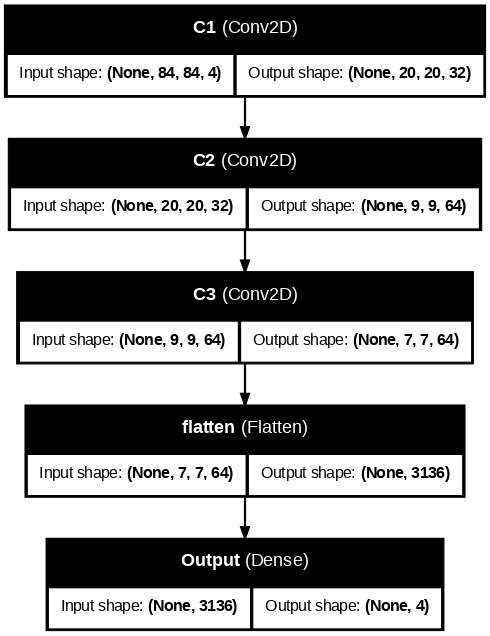

In [63]:
keras.utils.plot_model(dqn_action_model,show_shapes=True, show_layer_names=True,dpi=80)

## **Action model compilation**
The following code compiles the DQN model using the **compile** method.

Even if in the Deepmind paper the *RMSProp* algorithm has been used as optimizer, the *Adam* optimizer has been demonstrated to improve the training time.

Moreover, to increase the training stability, the *Huber* loss function is used instead of the *mean squared error* (MSE).

<u>Note that, only the action model is compiled because, during the training process, only its weights are updated using *gradient descent* algorithm. Target model weights are periodically replaced by those of the action model.</u>

In [64]:
learning_rate=0.00025

optimizer=keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
dqn_action_model.compile(optimizer=optimizer, loss = 'huber')

## **Input preprocessing**
To reduce the state complexity, and consequently the computation time, each frame is:
1. transformed in grayscale;
2. cropped to select the region of interest;
3. resized to 84×84.

Moreover, to reduce the memory occupation of the replay buffer, pixel values are stored as bytes (in the range [0;255]) and converted in floating-point values (in the range [0;1]) only when needed as input for the *action* or *target* models.

The following function performs such operations, given:
- the input frame (*frame*);
- the coordinates of the region of interest (*top_crop*, *bottom_crop*, *left_crop* and *right_crop*);
- the dimension of the resided frame (*resized_shape*).


In [69]:
def preprocess_frame(frame,top_crop,bottom_crop,left_crop,right_crop,resized_shape):
    # 1. the input RGB frame is transformed in grayscale
    gray = rgb2gray(frame)

    # 2. the region of interest is cropped
    cropped_frame = gray[top_crop:bottom_crop,left_crop:right_crop]

    # 3. the resulting images is resized
    preprocessed_frame = transform.resize(cropped_frame, resized_shape)

    # convert float to byte
    byte_preprocessed_frame=(preprocessed_frame*255).astype('uint8')

    return byte_preprocessed_frame

The code below shows an example of input frame and the result obtained by the **preprocess_frame** function.

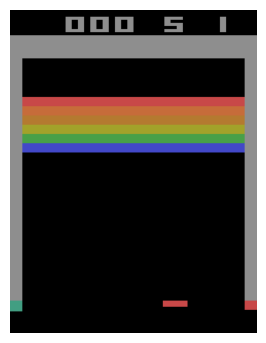

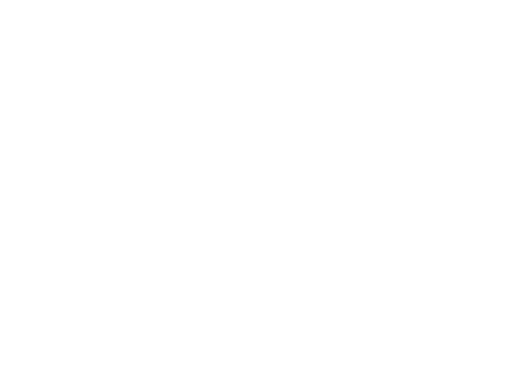

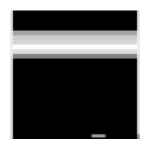

In [70]:
top_crop = 30             # y coordinate of the top of the region of interest
bottom_crop = 195         # y coordinate of the bottom of the region of interest
left_crop = 5             # x coordinate of the left of the region of interest
right_crop = 155          # x coordinate of the right of the region of interest
resized_shape = (84,84)   # shape of the resized frame

preprocessed_prev_frame=preprocess_frame(prev_screen,top_crop,bottom_crop,left_crop,right_crop,resized_shape)

dpi=50

plt.figure(figsize=(prev_screen.shape[1]/dpi,prev_screen.shape[0]/dpi))
plt.axis('off')
plt.imshow(prev_screen)
plt.show()

plt.axis('off')
plt.figure(figsize=(preprocessed_prev_frame.shape[1]/dpi,preprocessed_prev_frame.shape[0]/dpi))
plt.axis('off')
plt.imshow(preprocessed_prev_frame.squeeze(),cmap='gray')
plt.show()

## **Frame stacking**
To solve the problem of temporal limitation and give the network the sense of motion, DQN takes a stack of frames as input.

The following function stacks frames together given:
- the new frame to add (*new_frame*);
- the number of frames to stack (*frame_count*);
- the previous frames contained in a **deque** object (*deque_frames*).

For the first *new_frame*, *frame_count* frames identical to *new_frame* are added to a new **deque** object. Otherwise, the *new_frame* is appended to the deque that automatically removes the oldest frame.

In [72]:
def stack_frames(new_frame,frame_count,deque_frames=None):
  if deque_frames is None:
    deque_frames = deque([new_frame for i in range(frame_count)],maxlen=frame_count)
  else:
    deque_frames.append(new_frame)

  return np.stack(deque_frames, axis=2),deque_frames

The code below shows the result obtained by the **stack_frame** funciton with an initial frame as input.

Shape of the stacked frames (84, 84, 4)


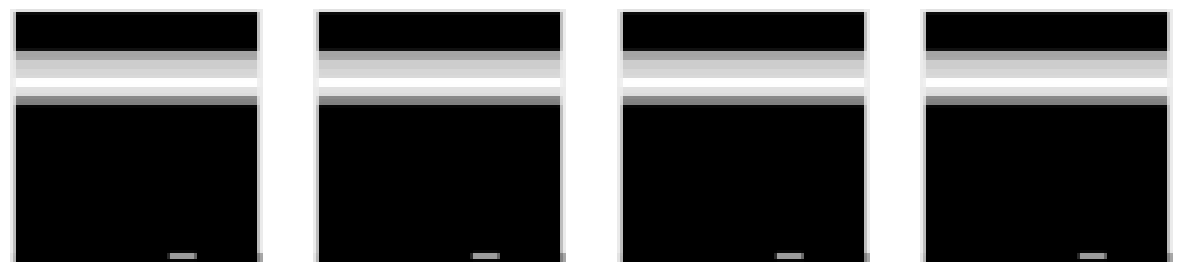

In [74]:
stacked_frame_count=4     # number of stacked frames

stacked_frames,deque_frames=stack_frames(preprocessed_prev_frame,stacked_frame_count)

print('Shape of the stacked frames',stacked_frames.shape)

plot_stacked_frames(stacked_frames)

The following code shows an example of stacked frames obtained performing random actions.

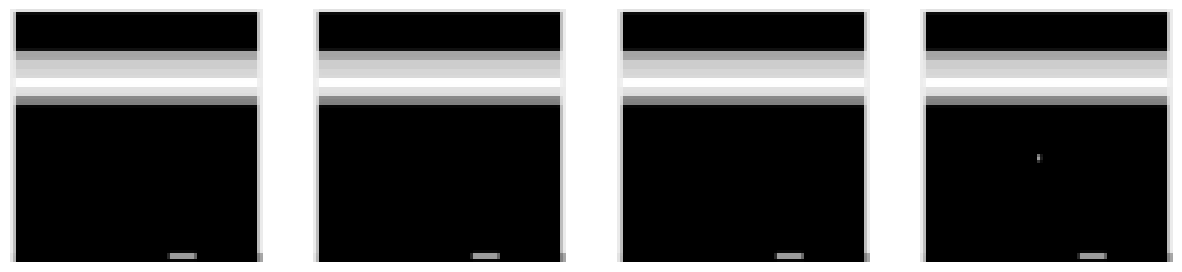

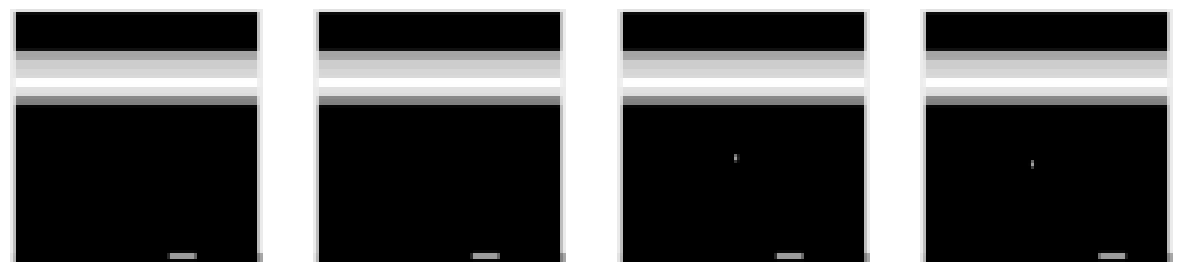

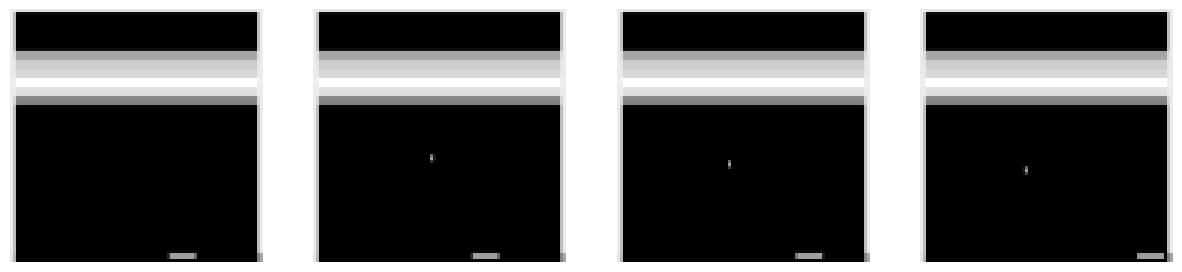

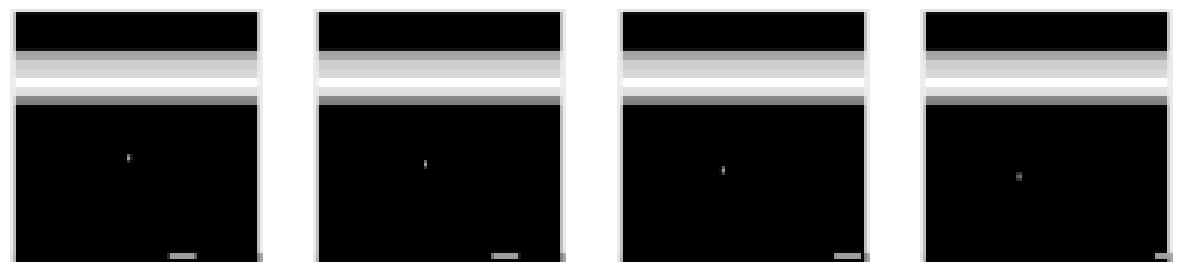

In [75]:
step_count=4

for i in range(step_count):
  new_state,_,_,_,_=env.step(1 if i==0 else env.action_space.sample())  # the first action is 'fire' to start the game
  new_frame=preprocess_frame(new_state,top_crop,bottom_crop,left_crop,right_crop,resized_shape)
  stacked_frames,deque_frames=stack_frames(new_frame,stacked_frame_count,deque_frames)
  plot_stacked_frames(stacked_frames)

## **Redefinition of some functions**
Since now the state of the environment is represented by a stack of preprocessed frames, some functions previously defined need to be modified accordingly.

### **Replay memory initialization**
The following function initializes the replay memory given:
- the environment (*env*);
- the replay memory (*replay_memory*);
- the number of transitions to be stored in the replay memory (*replay_memory_init_size*);
- the maximum number of steps per episode (*episode_max_steps*);
- the region of interest coordinates (*top_crop*, *bottom_crop*, *left_crop* and *right_crop*);
- the dimension of the resided frames (*resized_shape*);
- the number of stacked frames (*stacked_frame_count*) as input parameters.

Differently from **simple_dqn_replay_memory_init** function defined above, **dqn_replay_memory_init** uses the just defined **preprocess_frame** and **stack_frames** functions to create a stack of preprocessed frames to be stored into the replay memory from the states returned by the environment.


In [ ]:
def dqn_replay_memory_init(env,replay_memory,replay_memory_init_size,episode_max_steps,
                           top_crop,bottom_crop,left_crop,right_crop,resized_shape,stacked_frame_count):
    while True:
        state, _ = env.reset()

        # the state is preprocessed to obtain the initial frame
        frame = preprocess_frame(state,top_crop,bottom_crop,left_crop,right_crop,resized_shape)

        # a new stack of frames is created from the initial frame
        stacked_frames,deque_frames = stack_frames(frame,stacked_frame_count)

        done=False
        step_count=0
        while (step_count<episode_max_steps) and (not done):
            action = env.action_space.sample()
            new_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # the new frame is obtained by new state preprocessing
            new_frame = preprocess_frame(new_state,top_crop,bottom_crop,left_crop,right_crop,resized_shape)

            # the stack is updated by adding the new frame and removing the oldest one
            new_stacked_frames,deque_frames = stack_frames(new_frame,stacked_frame_count,deque_frames)

            replay_memory.append([stacked_frames,action,reward,new_stacked_frames,done])
            stacked_frames=new_stacked_frames
            step_count+=1
            if len(replay_memory)>=replay_memory_init_size:
                return

### **Action model update**
The following function updates action model weights using *gradient descent* algorithm given:
- the action model (*dqn_action_model*);
- the target model (*dqn_target_model*);
- a mini-batch containing transitions $<s_i,a_i,r_{i+1},s_{i+1}>$ randomly selected from the replay memory (*mini_batch*);
- the discount factor $\gamma$ (gamma).

With respect to **simple_dqn_update** function, here the pixel values contained in $s_i$ and $s_{i+1}$ (*state_batch* and *new_state_batch*, respectively) are normalized in the range $[0;1]$ before they being used as input of **predict** and **train_on_batch** methods.

In [77]:
def dqn_update(dqn_action_model,dqn_target_model,mini_batch,gamma):
  # the transition mini-batch is divided into a mini-batch for each element of a transition
  state_batch,action_batch,reward_batch,new_state_batch,done_batch=mini_batch

  # pixel values are normalized in the range [0;1]
  norm_state_batch=state_batch/255.0
  norm_new_state_batch=new_state_batch/255.0

  # find the target model Q values for all possible actions given the new state batch
  target_new_state_q_values = dqn_target_model.predict(norm_new_state_batch,verbose=0)

  # find the action model Q values for all possible actions given the current state batch
  predicted_state_q_values = dqn_action_model.predict(norm_state_batch,verbose=0)

  # estimate the target values y_i
  # for the action we took, use the target model Q values
  # for other actions, use the action model Q values
  # in this way, loss function will be 0 for other actions
  for i,(a,r,new_state_q_values, done) in enumerate(zip(action_batch,reward_batch,target_new_state_q_values, done_batch)):
      if not done:
        target_value = r + gamma * np.amax(new_state_q_values)
      else:
        target_value = r
      predicted_state_q_values[i][a] = target_value #y_i

  # update weights of action model using the train_on_batch method
  dqn_action_model.train_on_batch(norm_state_batch, predicted_state_q_values)

  # return the updated action model
  return dqn_action_model

## **Exercise 4: Atari DQN training algorithm**
Implement the following function to train an Atari DQN model given:
- the environment (*env*);
- the action model (*dqn_action_model*);
- the target model (*dqn_target_model*);
- the number of episodes (*episode_count*);
- the maximum number of steps per episode (*episode_max_steps*);
- the maximum number of transitions stored into the replay memory (*replay_memory_max_size*);
- the number of transitions stored into the replay memory before starting the training process (*replay_memory_init_size*);
- the mini-batch size (*batch_size*);
- the number ($u$) of total steps executed ($T$) between successive updates of the action model weights (*step_per_update*);
- the number ($c$) of total steps executed ($T$) between successive replaces of the target model weights with the weights of the action model (*step_per_update_target_model*);
- the maximum value of $\epsilon$ (*max_epsilon*);
- the minimum value of $\epsilon$ (*min_epsilon*);
- the $\epsilon$ decay value (*epsilon_decay*);
- the discount factor $\gamma$ (gamma);
- the coordinates of the region of interest (*top_crop*, *bottom_crop*, *left_crop* and *right_crop*);
- the dimension of the resided frames (*resized_shape*);
- the number of stacked frames (*stacked_frame_count*);
- the number of consecutive episodes to be considered in the calculation of the total reward moving average (*moving_avg_window_size*);
- the minimum value of the total reward moving average to consider the task solved (*moving_avg_stop_thr*). A value of *None* force to execute all *episode_count* episodes.

It could be useful to start from **simple_dqn_training** function defined above.

The following parts need to be modified with respect to **simple_dqn_training** function:
1. call the **dqn_replay_memory_init** function to populate the replay memory before starting the training process;
2. at the beginning of a new episode, use the **preprocess_frame** function to elaborate the initial state returned by the **reset** method of the environment (*env*) to obtain the first frame;
3. use the **stack_frames** function to create a new stack of frames initialized with the first frame;
4. before using the **predict** method of the action model to obtain the Q-values of each available actions given the current state ($s_t$), the stacked frames need to be normalized in the range $[0;1]$;
5. after the selected action $a_t$ has been executed, call the **preprocess_frame** function to obtain the new frame from the new state $s_{t+1}$;
6. use the **stack_frames** function to update the stack of frames by adding the new frame and removing the oldest one;
7. if the action model weights need to be updated, call the **dqn_update** function defined above.

In [ ]:
def dqn_training(env,dqn_action_model,dqn_target_model,episode_count,episode_max_steps,replay_memory_max_size,replay_memory_init_size,
                 batch_size,step_per_update,step_per_update_target_model,max_epsilon,min_epsilon,epsilon_decay,gamma,
                 top_crop,bottom_crop,left_crop,right_crop,resized_shape,stacked_frame_count,
                 moving_avg_window_size=100,moving_avg_stop_thr=None):
    # experience replay memory declaration
    replay_memory= deque(maxlen=replay_memory_max_size)

    # 1. replay memory initial population
    if replay_memory_init_size>0:
        print('Replay memory initial population')
        dqn_replay_memory_init(env, replay_memory, replay_memory_init_size, episode_max_steps, top_crop, bottom_crop, left_crop, right_crop, resized_shape,stacked_frame_count)

    # 2. inizialize epsilon equal to max_epsilon
    epsilon = max_epsilon

    train_rewards=[]  # for visualization purposes

    train_step_count=0  #T
    for n in range(episode_count):
        # for visualization purposes
        episode_start_time = time.time()
        episode_reward = 0
        episode_epsilon=epsilon

        # 3. reset the environment
        state, _ = env.reset()
        frame = preprocess_frame(state, top_crop, bottom_crop, left_crop, right_crop, resized_shape)
        stacked_frame = stack_frames(frame, stacked_frame_count)

        step_count=0  #t
        done=False
        while step_count<episode_max_steps and not done:
            # 4. decide whether to pick a random action or to exploit the already computed Q-values
            if random.uniform(0,1) >= epsilon:
                action = env.action_space.sample()
            else:
                norm_stacked_frames = stacked_frame_count / 255.0
                # nota: prediction prendono robe in pacchetti, quindi dobbiamo andare a specificarlo
                q_values = dqn_action_model.predict(stacked_frame[np.newaxis], verbose = 0) # sta roba mi ha fregato
                action = np.argmax(q_values)

            # 5. take the action and observe the outcome state and reward
            new_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            new_frame = preprocess_frame(new_state, top_crop, bottom_crop, left_crop, right_crop, resized_shape)

            new_stacked_frames, deque_frames = stack_frames(new_frame, stacked_frame_count, deque_frames)

            # store transition in the replay memory
            replay_memory.append([state,action,reward,new_state,done])

            # update the current state
            state=new_state

            if train_step_count % step_per_update == 0 and len(replay_memory)>=batch_size:
                # 6. get a random mini-batch from the replay memory
                mini_batch = get_random_batch_from_replay_memory(replay_memory, batch_size)

                # update the action model weights calling the dqn_update function (see below)
                dqn_action_model=dqn_update(dqn_action_model,dqn_target_model,mini_batch,gamma)

            if train_step_count % step_per_update_target_model ==0:
                # 7. copy weights from action to target model
                dqn_target_model.set_weights(dqn_action_model.get_weights())

            # 8. reduce epsilon
            if epsilon > min_epsilon:
                epsilon = max(min_epsilon, epsilon - epsilon_decay)

            # increase episode step count and total step count
            step_count+=1
            train_step_count+=1

            # add the current reward to the episode total reward
            episode_reward += reward

        # put the episode total reward into a list for visualization purposes
        train_rewards.append(episode_reward)

        # for visualization purposes
        episode_finish_time=time.time()
        episode_elapsed_time=episode_finish_time-episode_start_time
        episode_avg_step_time=episode_elapsed_time/step_count
        moving_avg_reward=statistics.mean(train_rewards[-moving_avg_window_size:])
        print("Episode: {} Steps: {}[{}] Epsilon: {:.3f} Time: {:.1f}s[{:.2f}s]  Total reward: {}[{:.1f}]".format(n,
                                                                                                                  step_count,
                                                                                                                  train_step_count,
                                                                                                                  episode_epsilon,
                                                                                                                  episode_elapsed_time,
                                                                                                                  episode_avg_step_time,
                                                                                                                  episode_reward,
                                                                                                                  moving_avg_reward))

        # condition to consider the task solved
        if (moving_avg_stop_thr is not None) and moving_avg_reward>moving_avg_stop_thr:
            break

    # return a list containing the total rewards of all training episodes
    return train_rewards

## **Training**
Now we are ready to start the training process by calling the **dqn_learning** function.

The following parameters must be set before being passed to the function:
- the number of episodes (*episode_count*);
- the maximum number of steps per episode (*episode_max_steps*);
- the maximum number of transitions stored into the replay memory (*replay_memory_max_size*);
- the number of transitions stored into the replay memory before starting the training process (*replay_memory_init_size*);
- the mini-batch size (*batch_size*);
- the number of total steps executed between successive updates of the action model weights (*step_per_update*);
- the number of total steps executed between successive replaces of the target model weights with the weights of the action model (*step_per_update_target_model*);
- the maximum value of $\epsilon$ (*max_epsilon*);
- the minimum value of $\epsilon$ (*min_epsilon*);
- the $\epsilon$ decay value (*epsilon_decay*);
- the discount factor $\gamma$ (gamma);
- the coordinates of the region of interest (*top_crop*, *bottom_crop*, *left_crop* and *right_crop*);
- the dimension of the resided frame (*resized_shape*);
- the number of stacked frames (*stacked_frame_count*);
- the number of consecutive episodes to be considered in the calculation of the total reward moving average (*moving_avg_window_size*);
- the minimum value of the total reward moving average to consider the task solved (*moving_avg_stop_thr*).

In [81]:
episode_count = 5                   # Total number of training episodes
episode_max_steps= 10000            # Maximum number of steps per episode

replay_memory_max_size = 100000     # The maximum number of transitions stored into the replay memory. The Deepmind paper suggests 1M however this may cause memory issues.
replay_memory_init_size= 5000       # The maximum number of transitions stored into the replay memory. The Deepmind paper suggests 50K.
batch_size = 32                     # The mini-batch size

step_per_update = 4                 # The number of total steps executed between successive updates of the action model weights
step_per_update_target_model=10000  # The number of total steps executed between successive replaces of the target model weights

max_epsilon=1.0                     # Exploration probability at start
min_epsilon=0.1                     # Minimum exploration probability
epsilon_decay=(max_epsilon-min_epsilon) / 1000000.0  # Decay for exploration probability

gamma = 0.99                        # Discount factor

top_crop = 30                       # y coordinate of the top of the region of interest
bottom_crop = 195                   # y coordinate of the bottom of the region of interest
left_crop = 5                       # x coordinate of the left of the region of interest
right_crop = 155                    # x coordinate of the right of the region of interest
resized_shape = (84,84)             # shape of the resized frame
stacked_frame_count=4               # number of stacked frames

moving_avg_window_size=100          # Number of consecutive episodes to be considered in the calculation of the total reward moving average
moving_avg_stop_thr=60              # Minimum value of the total reward moving average to consider the task solved

train_start_time=time.time()
train_rewards=dqn_training(env,
                          dqn_action_model,
                          dqn_target_model,
                          episode_count,
                          episode_max_steps,
                          replay_memory_max_size,
                          replay_memory_init_size,
                          batch_size,
                          step_per_update,
                          step_per_update_target_model,
                          max_epsilon,
                          min_epsilon,
                          epsilon_decay,
                          gamma,
                          top_crop,
                          bottom_crop,
                          left_crop,
                          right_crop,
                          resized_shape,
                          stacked_frame_count,
                          moving_avg_window_size,
                          moving_avg_stop_thr)

train_finish_time=time.time()
train_elapsed_time=train_finish_time-train_start_time
train_avg_episode_time=train_elapsed_time/episode_count
print("Train time: {:.1f}m [{:.1f}s]".format(train_elapsed_time/60.0,train_avg_episode_time))

Replay memory initial population


ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 with name 'None' of layer 'C1' is incompatible with the layer: expected axis -1 of input shape to have value 4, but received input with shape (1, 210, 160, 3)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(1, 210, 160, 3), dtype=uint8)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

### **Visualize the training process**
The following code uses the **plot_training_rewards** function to draw in a graph the total reward and its moving average reached during the different episodes of the training process.

In [ ]:
plot_training_rewards(train_rewards,moving_avg_window_size)

## **Performance evaluation**
The Deepmind original DQN model has been trained for a total of 50 million frames (about 38 days of game experience).

Unfortunately, we do not have neither enough time nor hardware resources on *Colab* to train such model.

In this section a DQN model trained for more than 10 million frames (22751 episodes) in about 11 days is evaluated.

The training process has been performed on an *Intel Xeon W-2133 CPU @3.60GHz 32GB of RAM with an NVIDIA GeForce GTX 1080 Ti GPU* changing the following hyper-parameters:
- the number of episodes (*episode_count=50000*);
- the maximum number of transitions stored into the replay memory (*replay_memory_max_size=250000*);
- the number of transitions stored into the replay memory before starting the training process (*replay_memory_init_size=50000*).

To evaluate the model improvement during the training phase, its weights have been saved after 5000 and 15000 episodes.

The graph below shows the total reward trend over the entire training process.

<img src=https://biolab.csr.unibo.it/ferrara/Courses/DL/Tutorials/RL/BreakoutDeterministic-v4_DQNTrainingRewards.png width="1200">

### **Model trained for 5000 episodes**
The DQN model weights obtained after 5000 episodes (about 1.9 million frames) can be loaded by executing the following code.

In [ ]:
dqn_model=build_dqn(action_count=int(env.action_space.n))
dqn_model.load_weights('/content/breakout_weights/BreakoutDeterministic-v4_DQN_Weights_5000ep.h5')

The following code executes an episode using the pre-trained DQN network and stores all frames into a list (*visualization_frames*).

In [ ]:
eval_max_step=1500

state, _ = env.reset()
frame = preprocess_frame(state,top_crop,bottom_crop,left_crop,right_crop,resized_shape)
stacked_frames,deque_frames = stack_frames(frame,stacked_frame_count)

visualization_frames=[]
episode_reward=0
step_count=0
done=False
while step_count<eval_max_step and not done:
    visualization_frame = env.render()
    visualization_frames.append(visualization_frame)

    q_values = dqn_model.predict(stacked_frames[np.newaxis]/255.0,verbose=0)
    action = np.argmax(q_values)

    new_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    new_frame = preprocess_frame(new_state,top_crop,bottom_crop,left_crop,right_crop,resized_shape)
    new_stacked_frames,deque_frames = stack_frames(new_frame,stacked_frame_count,deque_frames)
    stacked_frames=new_stacked_frames

    episode_reward+=reward
    step_count+=1

print('Steps: {} Total reward: {}'.format(step_count,episode_reward))

Then the MP4 video file, created using the **create_mp4_video_from_frames** function, is included into an HTML video tag.

In [ ]:
vide_file_name=create_mp4_video_from_frames(visualization_frames,30)

mp4 = open(vide_file_name,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(""" <video controls><source src="%s" type="video/mp4"></video>""" % data_url)

The agent is able to follow and hit the ball but without a specific game strategy. Moreover, when the ball increases its speed, the agent is no longer able to hit it.

### **Model trained for 15000 episodes**
The DQN model weights obtained after 15000 episodes (about 6.8 million frames) can be loaded by executing the following code.

In [ ]:
dqn_model=build_dqn(action_count=int(env.action_space.n))
dqn_model.load_weights('/content/breakout_weights/BreakoutDeterministic-v4_DQN_Weights_15000ep.h5')

The following code executes an episode using the pre-trained DQN network and stores all frames into a list (*visualization_frames*).

In [ ]:
eval_max_step=500

state, _ = env.reset()
frame = preprocess_frame(state,top_crop,bottom_crop,left_crop,right_crop,resized_shape)
stacked_frames,deque_frames = stack_frames(frame,stacked_frame_count)

visualization_frames=[]
episode_reward=0
step_count=0
done=False
while step_count<eval_max_step and not done:
    visualization_frame = env.render()
    visualization_frames.append(visualization_frame)

    q_values = dqn_model.predict(stacked_frames[np.newaxis]/255.0,verbose=0)
    action = np.argmax(q_values)

    new_state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

    new_frame = preprocess_frame(new_state,top_crop,bottom_crop,left_crop,right_crop,resized_shape)
    new_stacked_frames,deque_frames = stack_frames(new_frame,stacked_frame_count,deque_frames)
    stacked_frames=new_stacked_frames

    episode_reward+=reward
    step_count+=1

print('Steps: {} Total reward: {}'.format(step_count,episode_reward))

Then the MP4 video file, created using the **create_mp4_video_from_frames** function, is included into an HTML video tag.

In [ ]:
vide_file_name=create_mp4_video_from_frames(visualization_frames,30)

mp4 = open(vide_file_name,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(""" <video controls><source src="%s" type="video/mp4"></video>""" % data_url)

The agent is able to follow and hit the ball but without a specific game strategy.

Moreover, to prevent to lose the game, the agent has learned to not pull the last ball (*fire*). To avoid this behavior, we can force the agent to pull the ball at the beginning of each new round using the following code.

In [ ]:
state, _ = env.reset()
frame = preprocess_frame(state,top_crop,bottom_crop,left_crop,right_crop,resized_shape)
stacked_frames,deque_frames = stack_frames(frame,stacked_frame_count)

visualization_frames=[]
episode_reward=0
step_count=0
prev_lives_count=6
cur_lives_count=5
done=False
while True and not done:
    visualization_frame = env.render()
    visualization_frames.append(visualization_frame)

    if prev_lives_count>cur_lives_count:
      action=1
    else:
      q_values = dqn_model.predict(stacked_frames[np.newaxis]/255.0,verbose=0)
      action = np.argmax(q_values)

    new_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    new_frame = preprocess_frame(new_state,top_crop,bottom_crop,left_crop,right_crop,resized_shape)
    new_stacked_frames,deque_frames = stack_frames(new_frame,stacked_frame_count,deque_frames)
    stacked_frames=new_stacked_frames

    prev_lives_count=cur_lives_count
    cur_lives_count=info['lives']

    episode_reward+=reward
    step_count+=1

print('Steps: {} Total reward: {}'.format(step_count,episode_reward))

Then the MP4 video file, created using the **create_mp4_video_from_frames** function, is included into an HTML video tag.

In [ ]:
vide_file_name=create_mp4_video_from_frames(visualization_frames,30)

mp4 = open(vide_file_name,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(""" <video controls><source src="%s" type="video/mp4"></video>""" % data_url)

### **Final model**
The DQN model weights obtained at the end of the training phase can be loaded by executing the following code.

In [ ]:
dqn_model=build_dqn(action_count=int(env.action_space.n))
dqn_model.load_weights('/content/breakout_weights/BreakoutDeterministic-v4_DQN_Weights_22751ep.h5')

The following code executes an episode using the pre-trained DQN network and stores all frames into a list (*visualization_frames*).

In [ ]:
state, _ =env.reset()
frame = preprocess_frame(state,top_crop,bottom_crop,left_crop,right_crop,resized_shape)
stacked_frames,deque_frames = stack_frames(frame,stacked_frame_count)

visualization_frames=[]
episode_reward=0
step_count=0
prev_lives_count=6
cur_lives_count=5
done=False
while True and not done:
    visualization_frame = env.render()
    visualization_frames.append(visualization_frame)

    if prev_lives_count>cur_lives_count:
      action=1
    else:
      q_values = dqn_model.predict(stacked_frames[np.newaxis]/255.0,verbose=0)
      action = np.argmax(q_values)

    new_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    new_frame = preprocess_frame(new_state,top_crop,bottom_crop,left_crop,right_crop,resized_shape)
    new_stacked_frames,deque_frames = stack_frames(new_frame,stacked_frame_count,deque_frames)
    stacked_frames=new_stacked_frames

    prev_lives_count=cur_lives_count
    cur_lives_count=info['lives']

    episode_reward+=reward
    step_count+=1

print('Steps: {} Total reward: {}'.format(step_count,episode_reward))

Then the MP4 video file, created using the **create_mp4_video_from_frames** function, is included into an HTML video tag.

In [ ]:
vide_file_name=create_mp4_video_from_frames(visualization_frames,30)

mp4 = open(vide_file_name,'rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(""" <video controls><source src="%s" type="video/mp4"></video>""" % data_url)

Differently from previous models, this one has learned a precise game strategy: its objective is to to dig a tunnel and hit the blocks from above.

# **Exercise 5**
Solve another Gymnasium environment chosen from the following list:
- [Mountain Car](https://gymnasium.farama.org/environments/classic_control/mountain_car/);
- [Pendulum](https://gymnasium.farama.org/environments/classic_control/pendulum/);
- [Lunar Lander](https://gymnasium.farama.org/environments/box2d/lunar_lander/).